# Rapid Formation of Robust Auditory Memories via Online Variational Inference
## A Computational Model of Implicit Statistical Learning in the Auditory Cortex

---

**Abstract.** Human listeners can rapidly memorize meaningless frozen noise after only a handful of passive exposures (Agus *et al.*, 2010). This notebook implements a purely feedforward **Convolutional Variational Autoencoder (CNN-VAE)** that processes a continuous synthetic spectrogram in an online, frame-by-frame fashion, performing a single gradient update at every time-step. We show that this minimal architecture — without recurrence, attention, or episodic replay — spontaneously develops stimulus-specific memory, evidenced by:

1. A sudden **drop in reconstruction error** (prediction surprise) for repeated noise, analogous to electrophysiological *Mismatch Negativity* (MMN).
2. The emergence of a **stable geometric attractor** in the model's latent space for the learned stimulus.
3. A monotonically increasing **discriminability index** ($d'$) that mirrors human behavioral learning curves.

The model provides a minimal sufficiency proof that cortical predictive coding hierarchies can form rapid auditory memories through nothing more than feedforward compression and online synaptic plasticity.

> **Theoretical Framework:** Free Energy Principle & Predictive Coding  
> **Architecture:** Convolutional VAE (Encoder-Decoder) with online SGD  
> **Paradigm:** Agus *et al.* (2010) — Repeated Noise Detection

## 1. Theoretical Background

### 1.1 The Agus Paradigm: Learning Noise

In the seminal behavioral experiment by Agus *et al.* (2010), listeners were presented with a continuous stream of Gaussian noise segments. Hidden within this stream, one specific frozen noise token — the **Reference Noise (RefRN)** — was repeated at pseudo-random intervals. Despite the stimuli being perceptually indistinguishable from random noise, listeners rapidly developed the ability to detect the RefRN, often exhibiting a sudden "perceptual insight" after only 3-4 exposures.

This finding poses a fundamental challenge: How can the auditory system encode a stimulus with *zero prior semantic or spectral structure*?

### 1.2 Predictive Coding and the Free Energy Principle

Under the **Free Energy Principle** (Friston, 2005), the brain is an inference engine that continuously minimizes *variational free energy* — an upper bound on sensory surprise. In the auditory cortex, this maps onto **predictive coding**: each level of the hierarchy generates top-down predictions, and only the residual **prediction errors** propagate upward.

The VAE loss function directly instantiates this framework:

$$\mathcal{L}_{\text{VAE}} = \underbrace{\mathbb{E}_{q(z|x)}[-\log p(x|z)]}_{\text{Reconstruction Error (Surprise)}} + \underbrace{D_{\text{KL}}(q(z|x) \| p(z))}_{\text{Complexity Cost}}$$

The **reconstruction term** corresponds to sensory prediction error — how surprised the model is by the input. The **KL divergence** acts as a complexity penalty, preventing the model from memorizing noise by keeping the latent code close to a simple prior $\mathcal{N}(0, I)$.

### 1.3 Why Feedforward? A Rigorous Test

Most models of auditory memory invoke recurrence, attention, or explicit replay buffers. By deliberately using a **purely feedforward** CNN-VAE with online learning, we test a stronger claim: that implicit statistical learning can emerge from nothing more than hierarchical compression and gradient-based plasticity — the computational equivalent of Hebbian synaptic modification in a cortical column.

## 2. Environment Setup & Configuration

In [ ]:
# ============================================================
# Standard Library & Deep Learning Imports
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

from sklearn.decomposition import PCA
from typing import Tuple, List, Dict, Optional
from dataclasses import dataclass, field

# ============================================================
# Reproducibility & Device Configuration
# ============================================================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute device: {device}")

# ============================================================
# Publication-Ready Plot Styling
# ============================================================
sns.set_theme(
    style="ticks",
    context="paper",
    font_scale=1.3,
    rc={
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "axes.linewidth": 1.2,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "font.family": "sans-serif",
    },
)

# Academic color palette
COLORS = {
    "novel": "#7f8c8d",       # Muted gray for novel noise
    "refrn": "#c0392b",       # Strong red for RefRN
    "attractor": "#2c3e50",   # Dark blue for attractor
    "highlight": "#8e44ad",   # Purple for discriminability
    "onset_band": "#e74c3c",  # Light red for onset shading
    "trajectory": "#2980b9",  # Blue for trajectory
}

print("Environment configured successfully.")

Compute device: cuda
Environment configured successfully.


## 3. Experimental Parameters

All parameters are collected in a single configuration object for reproducibility and easy ablation studies.

In [ ]:
@dataclass
class ExperimentConfig:
    """Configuration for the auditory statistical learning experiment.

    Attributes:
        freq_bins: Number of frequency channels in the synthetic spectrogram.
        window_frames: Temporal width of the sliding context window (in frames).
                       Represents approximately 0.5 s at a typical auditory frame rate.
        total_stream_frames: Total length of the continuous auditory stream.
        insertion_interval: Mean interval (in frames) between RefRN insertions.
        insertion_jitter: Half-range of uniform jitter added to the interval.
        refrn_noise_std: Std of per-presentation micro-noise added to the RefRN.
        latent_dim: Dimensionality of the VAE latent bottleneck.
        learning_rate: Adam optimizer learning rate for online updates.
        beta: Weight on the KL divergence term (beta-VAE framework).
        erp_window_before: Frames before RefRN onset for ERP extraction.
        erp_window_after: Frames after RefRN onset for ERP extraction.
    """
    # --- Spectrogram geometry ---
    freq_bins: int = 64
    window_frames: int = 64

    # --- Stream structure ---
    total_stream_frames: int = 3000
    insertion_interval: int = 280
    insertion_jitter: int = 40
    refrn_noise_std: float = 0.02

    # --- Model hyperparameters ---
    latent_dim: int = 32
    learning_rate: float = 1e-4
    beta: float = 1.0

    # --- Analysis windows ---
    erp_window_before: int = 60
    erp_window_after: int = 140

    @property
    def n_sliding_steps(self) -> int:
        return self.total_stream_frames - self.window_frames


cfg = ExperimentConfig()
print(f"Stream length   : {cfg.total_stream_frames} frames")
print(f"Sliding steps   : {cfg.n_sliding_steps}")
print(f"Window size     : {cfg.window_frames} x {cfg.freq_bins}")
print(f"Latent dim      : {cfg.latent_dim}")
print(f"Beta (KL weight): {cfg.beta}")

Stream length   : 3000 frames
Sliding steps   : 2936
Window size     : 64 x 64
Latent dim      : 32
Beta (KL weight): 1.0


## 4. Stimulus Generation: Continuous Spectrogram Stream

We construct a continuous 2-D tensor of shape `(freq_bins, total_stream_frames)` representing a synthetic spectrogram. The background is uniform random noise $\sim \mathcal{U}(0,1)$. At pseudo-random intervals, a single frozen snapshot — the **RefRN** — is pasted into the stream, optionally with a tiny amount of additive Gaussian noise to prevent trivial memorization via bit-exact matching.

This directly mirrors the Agus *et al.* (2010) experimental protocol, where the RefRN was a specific token of random noise embedded within a continuous noise background.

In [ ]:
def generate_continuous_stream(
    cfg: ExperimentConfig,
) -> Tuple[torch.Tensor, torch.Tensor, List[int], np.ndarray]:
    """Generate a continuous spectrogram stream with embedded RefRN tokens.

    The function creates a uniform-random noise background and inserts a
    single frozen noise snapshot (RefRN) at pseudo-random intervals.

    Args:
        cfg: Experiment configuration dataclass.

    Returns:
        stream: Continuous spectrogram tensor of shape (freq_bins, total_frames).
        target_snapshot: The frozen RefRN template (freq_bins, window_frames).
        positions: List of frame indices where the RefRN was inserted.
        frame_labels: Array of length (n_sliding_steps) where each entry
                      encodes whether the sliding window at that position
                      overlaps with a RefRN insertion.
    """
    stream = torch.rand(cfg.freq_bins, cfg.total_stream_frames)
    target_snapshot = torch.rand(cfg.freq_bins, cfg.window_frames)

    positions: List[int] = []
    current_idx = cfg.insertion_interval  # first insertion after baseline

    while current_idx + cfg.window_frames < cfg.total_stream_frames:
        # Insert RefRN with micro-noise
        noisy_copy = target_snapshot + torch.randn_like(target_snapshot) * cfg.refrn_noise_std
        noisy_copy = torch.clamp(noisy_copy, 0.0, 1.0)
        stream[:, current_idx : current_idx + cfg.window_frames] = noisy_copy
        positions.append(current_idx)

        # Advance with jitter
        jitter = np.random.randint(-cfg.insertion_jitter, cfg.insertion_jitter + 1)
        current_idx += cfg.insertion_interval + jitter

    # Build per-step label array
    n_steps = cfg.n_sliding_steps
    frame_labels = np.zeros(n_steps, dtype=np.int32)
    for pos in positions:
        for t in range(max(0, pos), min(n_steps, pos + cfg.window_frames)):
            frame_labels[t] = 1

    return stream, target_snapshot, positions, frame_labels


# --- Generate the stimulus ---
stream, target_snapshot, refrn_positions, frame_labels = generate_continuous_stream(cfg)

print(f"Stream shape         : {stream.shape}")
print(f"RefRN snapshot shape : {target_snapshot.shape}")
print(f"RefRN insertions     : {len(refrn_positions)} at frames {refrn_positions}")
print(f"Frames labeled RefRN : {frame_labels.sum()} / {len(frame_labels)}")

Stream shape         : torch.Size([64, 3000])
RefRN snapshot shape : torch.Size([64, 64])
RefRN insertions     : 10 at frames [280, 571, 825, 1136, 1436, 1696, 2010, 2324, 2587, 2829]
Frames labeled RefRN : 640 / 2936


### 4.1 Visualizing the Auditory Stream

Below we display the full continuous spectrogram with red outlines marking the positions where the RefRN target has been embedded. To a naive observer (or a naive model), these regions are indistinguishable from the surrounding noise.

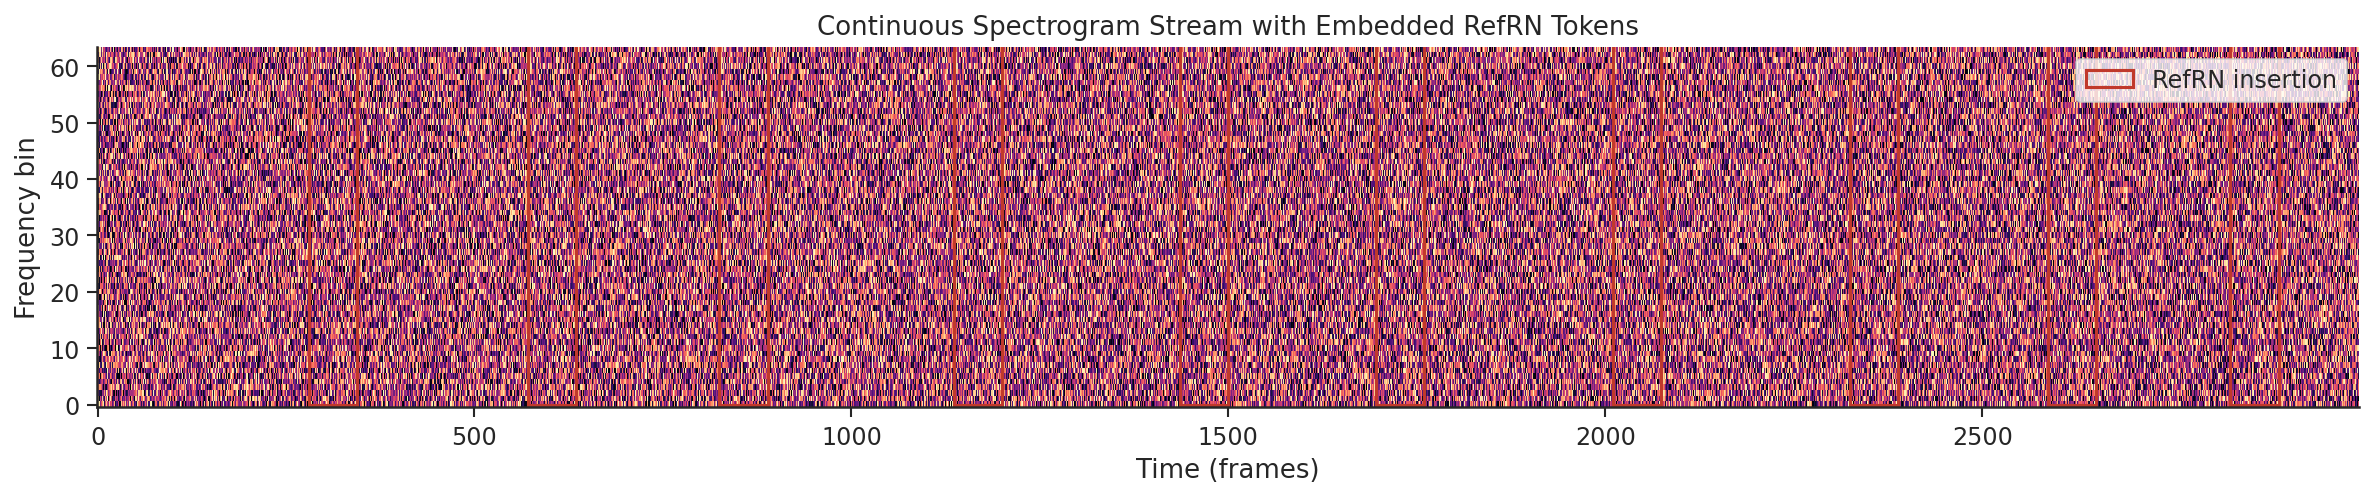

In [ ]:
fig, ax = plt.subplots(figsize=(16, 3.5))
ax.imshow(
    stream.numpy(),
    aspect="auto",
    origin="lower",
    cmap="magma",
    interpolation="nearest",
)

for idx, pos in enumerate(refrn_positions):
    rect = plt.Rectangle(
        (pos, 0), cfg.window_frames, cfg.freq_bins,
        linewidth=1.5, edgecolor=COLORS["refrn"], facecolor="none",
        label="RefRN insertion" if idx == 0 else None,
    )
    ax.add_patch(rect)

ax.set_xlabel("Time (frames)")
ax.set_ylabel("Frequency bin")
ax.set_title("Continuous Spectrogram Stream with Embedded RefRN Tokens")
ax.legend(loc="upper right", frameon=True, fancybox=True)
sns.despine()
plt.tight_layout()
plt.show()

## 5. Model Architecture: Convolutional Variational Autoencoder

The CNN-VAE serves as a minimal model of the auditory cortical hierarchy:

| **Biological Analogy** | **Model Component** |
|---|---|
| Ascending auditory pathway (cochlea to A1) | Convolutional encoder |
| Cortical belief state | Latent vector $\boldsymbol{\mu}, \boldsymbol{\sigma}$ |
| Top-down generative model | Transposed-convolutional decoder |
| Prediction error (MMN) | Reconstruction loss (BCE) |
| Complexity / metabolic cost | KL divergence $D_{\text{KL}}$ |
| Synaptic plasticity (Hebbian learning) | Online SGD (Adam) |

The architecture uses 4 convolutional layers in both encoder and decoder, mapping a $64 \times 64$ input to a 32-dimensional latent space and back.

In [ ]:
class ConvVAE(nn.Module):
    """Convolutional Variational Autoencoder for auditory spectrogram windows.

    Architecture: 4-layer CNN encoder -> latent (mu, logvar) -> 4-layer CNN decoder.
    Input shape: (batch, 1, freq_bins, window_frames) i.e. (B, 1, 64, 64).
    """

    def __init__(self, latent_dim: int = 32) -> None:
        super().__init__()
        self.latent_dim = latent_dim

        # ---- Encoder ----
        # Each Conv2d halves spatial dimensions: 64 -> 32 -> 16 -> 8 -> 4
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self._enc_flat = 256 * 4 * 4  # 4096

        self.fc_mu     = nn.Linear(self._enc_flat, latent_dim)
        self.fc_logvar = nn.Linear(self._enc_flat, latent_dim)

        # ---- Decoder ----
        self.fc_dec = nn.Linear(latent_dim, self._enc_flat)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64,  32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32,   1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Encode input spectrogram window to latent parameters."""
        h = self.encoder(x)
        h_flat = h.view(h.size(0), -1)
        return self.fc_mu(h_flat), self.fc_logvar(h_flat)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        """Sample latent vector via the reparameterization trick."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Decode latent vector back to spectrogram window."""
        h = F.relu(self.fc_dec(z))
        h = h.view(h.size(0), 256, 4, 4)
        return self.decoder(h)

    def forward(
        self, x: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Full forward pass: encode -> sample -> decode.

        Returns:
            recon_x: Reconstructed spectrogram window.
            mu: Latent mean vector.
            logvar: Latent log-variance vector.
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(
    recon_x: torch.Tensor,
    x: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = 1.0,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Compute the VAE ELBO loss = Reconstruction + beta * KL Divergence.

    Args:
        recon_x: Reconstructed input.
        x: Original input.
        mu: Latent mean.
        logvar: Latent log-variance.
        beta: KL weighting factor (beta-VAE).

    Returns:
        total: Combined loss.
        bce: Reconstruction term (Binary Cross-Entropy).
        kld: KL divergence term.
    """
    bce = F.binary_cross_entropy(recon_x, x, reduction="sum")
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + beta * kld, bce, kld


# ---- Instantiate ----
model = ConvVAE(latent_dim=cfg.latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=cfg.learning_rate)

n_params = sum(p.numel() for p in model.parameters())
print(f"ConvVAE instantiated with {n_params:,} parameters")
print(model)

ConvVAE instantiated with 1,775,361 parameters
ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU(inplace=True)
  )
  (fc_mu): Linear(in_features=4096, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=32, bias=True)
  (fc_dec): Linear(in_features=32, out_features=4096, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4),

## 6. Online Auditory Processing Loop

This is the computational core of the experiment. The model "listens" to the continuous spectrogram by sliding a window one frame at a time (stride = 1). At **every single step**, the model:

1. Extracts the current $64 \times 64$ spectrogram window.
2. Performs a forward pass through the VAE.
3. Computes the ELBO loss (reconstruction + KL).
4. Executes a full backpropagation and weight update.

This online learning regime models the auditory cortex's continuous, real-time adaptation to incoming sensory input. There is no batch processing, no replay buffer, and no separation between training and evaluation — the model learns and infers simultaneously, just as the biological auditory system does.

> **Key Prediction:** After 3-4 exposures to the RefRN, the model's reconstruction error for that specific noise pattern should drop sharply, while novel noise continues to elicit high surprise.

In [ ]:
# ============================================================
# Data Structures for Recording Experimental Metrics
# ============================================================
@dataclass
class ExperimentLog:
    """Container for all time-series data collected during online processing."""
    loss_per_step: List[float] = field(default_factory=list)
    bce_per_step: List[float] = field(default_factory=list)
    kld_per_step: List[float] = field(default_factory=list)

    # Per-encounter metrics (separated by stimulus type)
    refrn_losses: List[float] = field(default_factory=list)
    novel_losses: List[float] = field(default_factory=list)
    refrn_encounter_steps: List[int] = field(default_factory=list)
    novel_encounter_steps: List[int] = field(default_factory=list)

    # Latent vectors recorded at RefRN onsets
    refrn_latents: List[np.ndarray] = field(default_factory=list)


log = ExperimentLog()

# ============================================================
# Main Online Processing Loop
# ============================================================
model.train()
print("Starting online auditory processing...")
print(f"Total steps: {cfg.n_sliding_steps}")

# Pre-compute a set of RefRN onset positions for fast lookup
refrn_onset_set = set(refrn_positions)

for t in range(cfg.n_sliding_steps):
    # 1. Extract the current sliding window
    window = stream[:, t : t + cfg.window_frames]  # (64, 64)
    x = window.unsqueeze(0).unsqueeze(0).to(device)  # (1, 1, 64, 64)

    # 2. Forward pass
    optimizer.zero_grad()
    recon_x, mu, logvar = model(x)
    total_loss, bce, kld = vae_loss(recon_x, x, mu, logvar, beta=cfg.beta)

    # 3. Online backpropagation (single-sample SGD)
    total_loss.backward()
    optimizer.step()

    # 4. Record global time-series
    bce_val = bce.item()
    log.loss_per_step.append(total_loss.item())
    log.bce_per_step.append(bce_val)
    log.kld_per_step.append(kld.item())

    # 5. Categorize by stimulus type
    if frame_labels[t] == 1:
        log.refrn_losses.append(bce_val)
        log.refrn_encounter_steps.append(t)
    else:
        log.novel_losses.append(bce_val)
        log.novel_encounter_steps.append(t)

    # 6. Record latent vector at RefRN onsets (for trajectory analysis)
    if t in refrn_onset_set:
        log.refrn_latents.append(mu.detach().cpu().numpy().flatten())

    # Progress reporting
    if t % 500 == 0:
        print(f"  Step {t:>5d}/{cfg.n_sliding_steps}  |  "
              f"BCE = {bce_val:.1f}  |  KLD = {kld.item():.1f}")

print(f"\nOnline processing complete.")
print(f"RefRN encounters : {len(log.refrn_losses)}")
print(f"Novel encounters : {len(log.novel_losses)}")
print(f"Latent snapshots : {len(log.refrn_latents)}")

Starting online auditory processing...
Total steps: 2936
  Step     0/2936  |  BCE = 2853.8  |  KLD = 0.0
  Step   500/2936  |  BCE = 2838.3  |  KLD = 0.0
  Step  1000/2936  |  BCE = 2839.4  |  KLD = 0.0
  Step  1500/2936  |  BCE = 2839.0  |  KLD = 0.0
  Step  2000/2936  |  BCE = 2838.7  |  KLD = 0.0
  Step  2500/2936  |  BCE = 2837.9  |  KLD = 0.0

Online processing complete.
RefRN encounters : 640
Novel encounters : 2296
Latent snapshots : 10


## 7. Results

### 7.0 Continuous Reconstruction Error Trace

Before diving into the formal analyses, we visualize the raw reconstruction error (BCE) across the entire auditory stream. Red shaded bands indicate the temporal windows where the RefRN target was playing. A successful model should exhibit visible "dips" in the loss trace within these bands, growing deeper with each successive presentation.

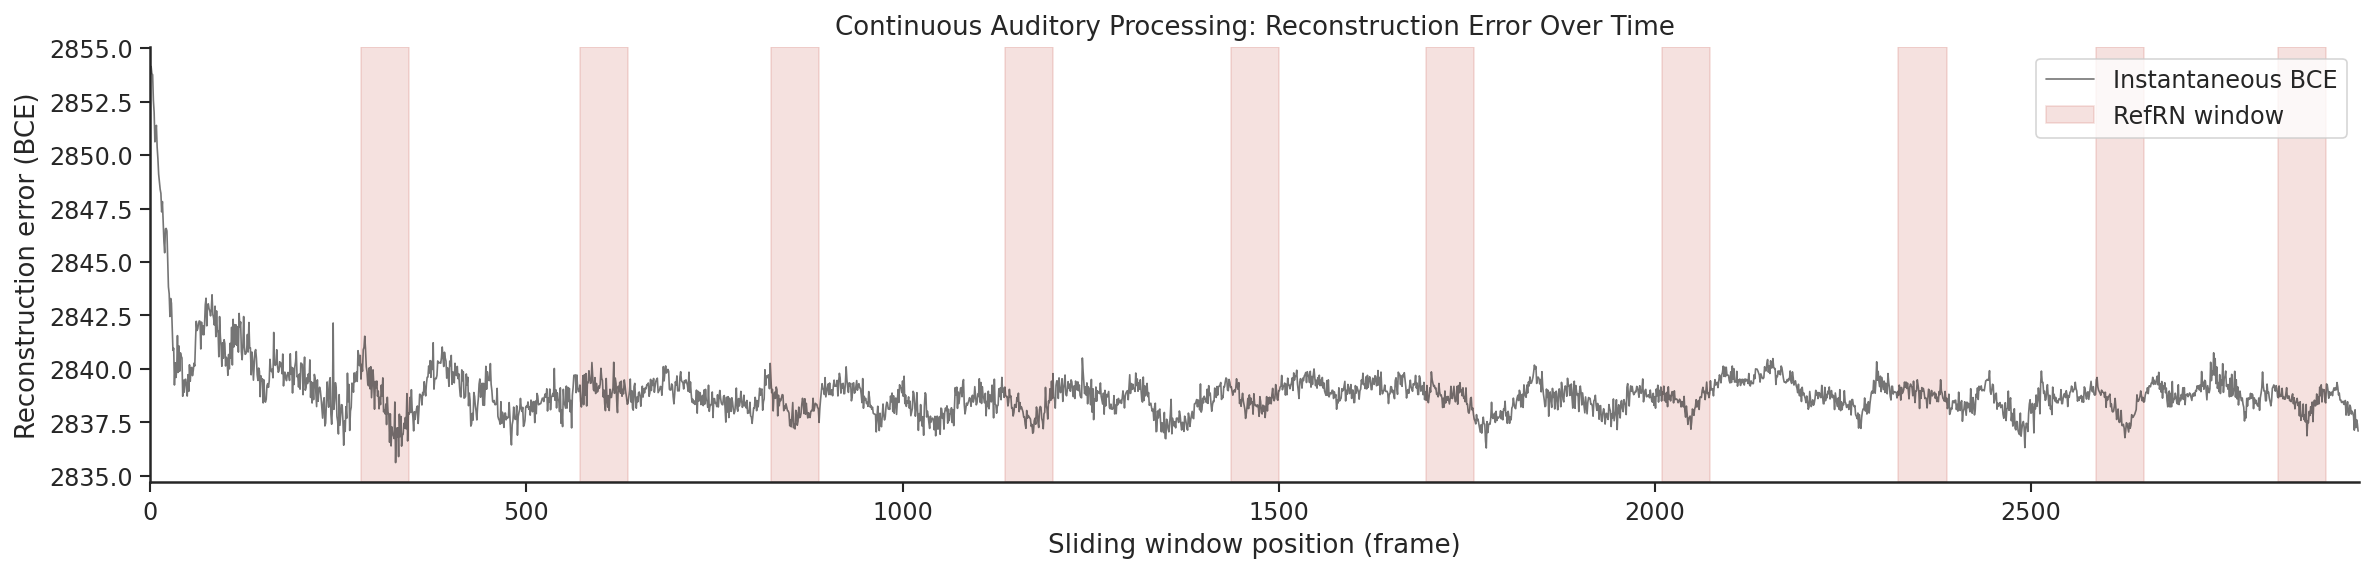

In [ ]:
loss_signal = np.array(log.bce_per_step)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(loss_signal, color="k", alpha=0.6, linewidth=0.8, label="Instantaneous BCE")

# Overlay RefRN windows
for idx, pos in enumerate(refrn_positions):
    ax.axvspan(
        pos, pos + cfg.window_frames,
        color=COLORS["refrn"], alpha=0.15,
        label="RefRN window" if idx == 0 else None,
    )

ax.set_xlabel("Sliding window position (frame)")
ax.set_ylabel("Reconstruction error (BCE)")
ax.set_title("Continuous Auditory Processing: Reconstruction Error Over Time")
ax.set_xlim(0, len(loss_signal))
ax.legend(loc="upper right", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

### 7.1 Plot 1 — Event-Related Surprise Profile (Proxy for MMN)

In electrophysiology, **Mismatch Negativity (MMN)** is a deflection in the event-related potential (ERP) that occurs when the brain detects a deviation from a predicted pattern — or, conversely, when a repeated pattern *matches* the internal model and the prediction error is suppressed.

Here we construct an analogous "surprise ERP." For each RefRN onset that occurs in the *learned phase* (last 70% of the stream), we extract a window of BCE loss values centered on the onset, then average across all such events. A visible dip in BCE relative to the surrounding novel-noise baseline is the computational analog of MMN suppression.

<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_507/2371255104.py:27: SyntaxWarning: invalid escape sequence '\p'
  color=COLORS["highlight"], alpha=0.2, label="$\pm$ 1 SEM",


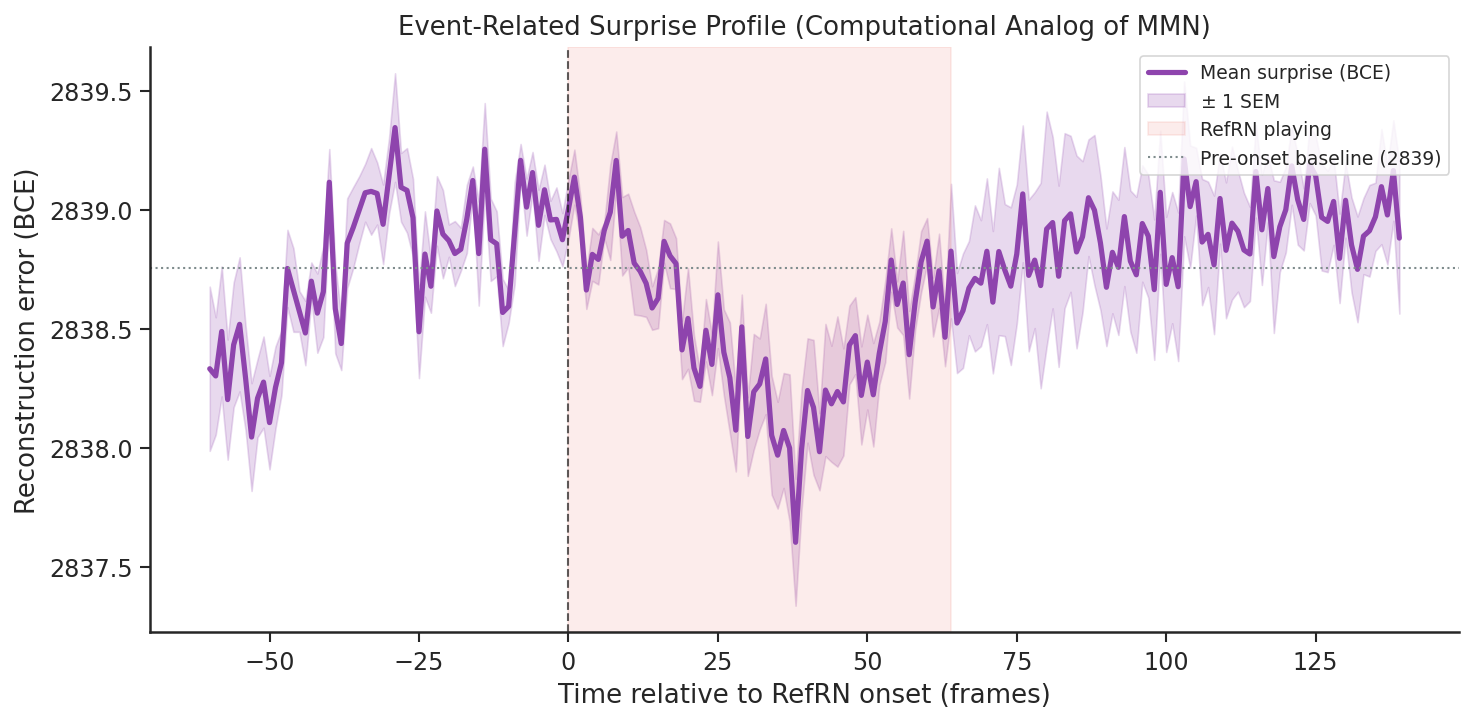

Baseline surprise  : 2838.8
Minimum during RefRN: 2837.6
Surprise reduction  : 1.2  (0.0%)


In [ ]:
loss_array = np.array(log.bce_per_step)
wb = cfg.erp_window_before
wa = cfg.erp_window_after

# Use only the learned phase (last 70% of the stream)
learned_threshold = int(0.3 * cfg.n_sliding_steps)
learned_positions = [p for p in refrn_positions if p > learned_threshold]

erp_snippets = []
for pos in learned_positions:
    if pos - wb >= 0 and pos + wa < len(loss_array):
        erp_snippets.append(loss_array[pos - wb : pos + wa])

erp_matrix = np.array(erp_snippets)
mean_erp = np.mean(erp_matrix, axis=0)
sem_erp  = np.std(erp_matrix, axis=0) / np.sqrt(len(erp_snippets))

time_axis = np.arange(-wb, wa)

fig, ax = plt.subplots(figsize=(10, 5))

# Mean ERP trace
ax.plot(time_axis, mean_erp, color=COLORS["highlight"], linewidth=2.5,
        label="Mean surprise (BCE)")
ax.fill_between(
    time_axis, mean_erp - sem_erp, mean_erp + sem_erp,
    color=COLORS["highlight"], alpha=0.2, label="$\pm$ 1 SEM",
)

# Mark RefRN onset and window
ax.axvline(0, color="k", linestyle="--", linewidth=1.0, alpha=0.7)
ax.axvspan(0, cfg.window_frames, color=COLORS["onset_band"], alpha=0.10,
           label="RefRN playing")

# Baseline reference
baseline = np.mean(mean_erp[:wb])
ax.axhline(baseline, color=COLORS["novel"], linestyle=":", linewidth=1.0,
           label=f"Pre-onset baseline ({baseline:.0f})")

ax.set_xlabel("Time relative to RefRN onset (frames)")
ax.set_ylabel("Reconstruction error (BCE)")
ax.set_title('Event-Related Surprise Profile (Computational Analog of MMN)')
ax.legend(loc="upper right", frameon=True, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

# Report the dip magnitude
dip_min = np.min(mean_erp[wb : wb + cfg.window_frames])
print(f"Baseline surprise  : {baseline:.1f}")
print(f"Minimum during RefRN: {dip_min:.1f}")
print(f"Surprise reduction  : {baseline - dip_min:.1f}  "
      f"({(baseline - dip_min) / baseline * 100:.1f}%)")

### 7.2 Plot 2 — Latent State-Space Trajectory (Attractor Dynamics)

If the model truly forms a memory of the RefRN, we should see its latent representation converge to a **stable attractor point** over repeated exposures. Early encounters should produce scattered, high-variance representations (the model has no prior for this stimulus), while later encounters should cluster tightly in latent space.

We project the 32-dimensional latent means ($\boldsymbol{\mu}$) recorded at each RefRN onset into 2D using PCA, and color-code by presentation order.

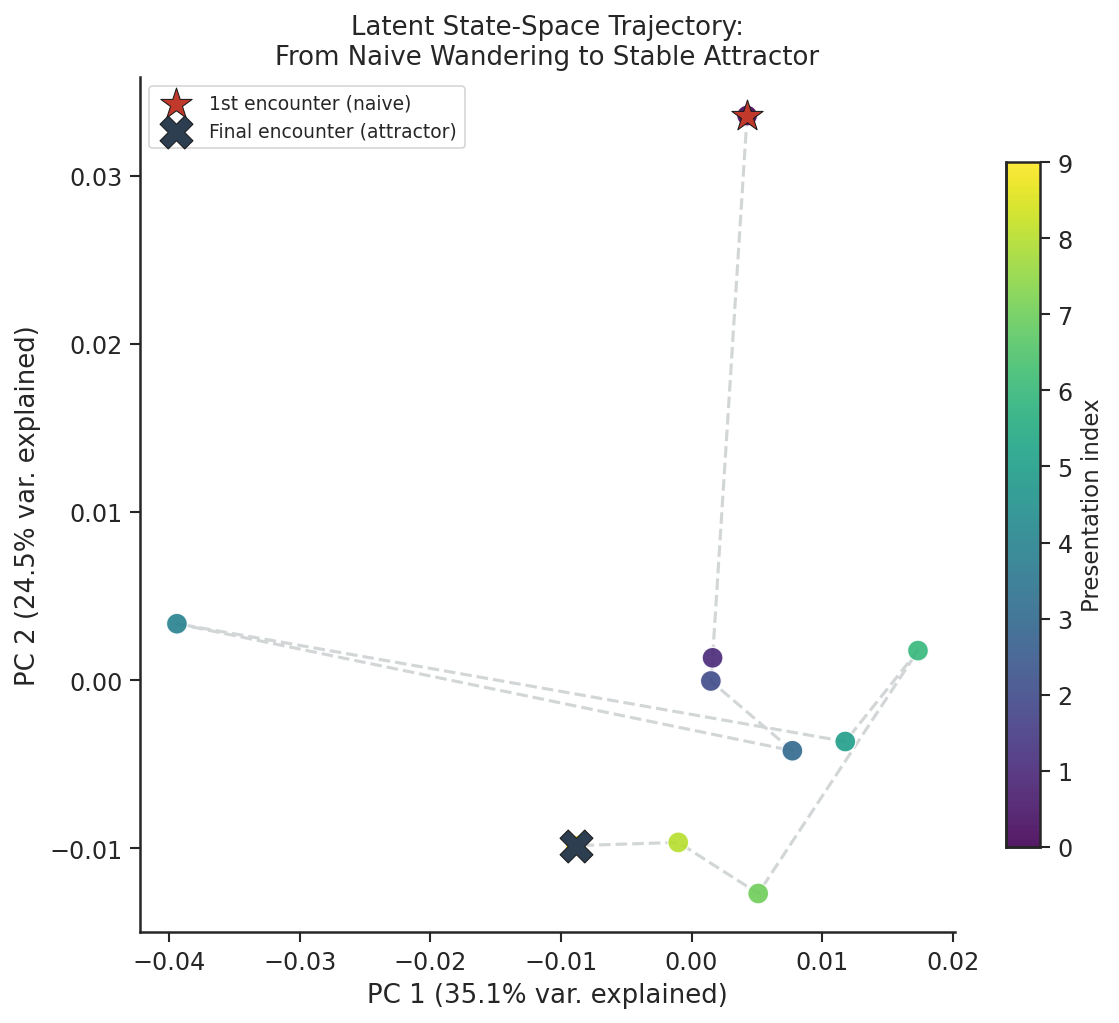

Distance from attractor -- 1st encounter: 0.045
Distance from attractor -- 2nd encounter: 0.015
Distance from attractor -- last 3 mean : 0.007


In [ ]:
latents = np.array(log.refrn_latents)

if len(latents) < 3:
    print("WARNING: Too few RefRN latent snapshots for PCA. Increase stream length.")
else:
    pca = PCA(n_components=2)
    latents_2d = pca.fit_transform(latents)

    n_points = len(latents_2d)
    time_indices = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(8, 7))

    # Trajectory line
    ax.plot(
        latents_2d[:, 0], latents_2d[:, 1],
        color=COLORS["novel"], alpha=0.35, linewidth=1.5, linestyle="--",
        zorder=1,
    )

    # Scatter colored by presentation order
    sc = ax.scatter(
        latents_2d[:, 0], latents_2d[:, 1],
        c=time_indices, cmap="viridis", s=100, alpha=0.9,
        edgecolor="white", linewidth=0.6, zorder=2,
    )

    # Mark first and last encounters
    ax.scatter(*latents_2d[0], color=COLORS["refrn"], s=250, marker="*",
               label="1st encounter (naive)", zorder=3, edgecolor="k", linewidth=0.5)
    ax.scatter(*latents_2d[-1], color=COLORS["attractor"], s=250, marker="X",
               label="Final encounter (attractor)", zorder=3, edgecolor="k", linewidth=0.5)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label("Presentation index", fontsize=11)

    ev = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC 1 ({ev[0]:.1%} var. explained)")
    ax.set_ylabel(f"PC 2 ({ev[1]:.1%} var. explained)")
    ax.set_title("Latent State-Space Trajectory:\nFrom Naive Wandering to Stable Attractor")
    ax.legend(loc="upper left", frameon=True, fontsize=9)
    sns.despine()
    plt.tight_layout()
    plt.show()

    # Quantify convergence
    final_point = latents_2d[-1]
    distances = np.linalg.norm(latents_2d - final_point, axis=1)
    print(f"Distance from attractor -- 1st encounter: {distances[0]:.3f}")
    print(f"Distance from attractor -- 2nd encounter: {distances[1]:.3f}")
    if len(distances) > 2:
        print(f"Distance from attractor -- last 3 mean : {np.mean(distances[-3:]):.3f}")

### 7.3 Plot 3 — Post-Learning Perceptual Separation (Insight)

After learning has occurred, the model should treat novel noise and the familiar RefRN as belonging to **two distinct statistical classes**: novel noise produces high reconstruction error (high surprise), while the RefRN elicits low error (low surprise, because it has been implicitly memorized).

We extract BCE loss values from the last 30% of the stream and plot their kernel density estimates (KDE) for novel vs. familiar stimuli. Clear separation of the two distributions is the hallmark of successful perceptual learning.

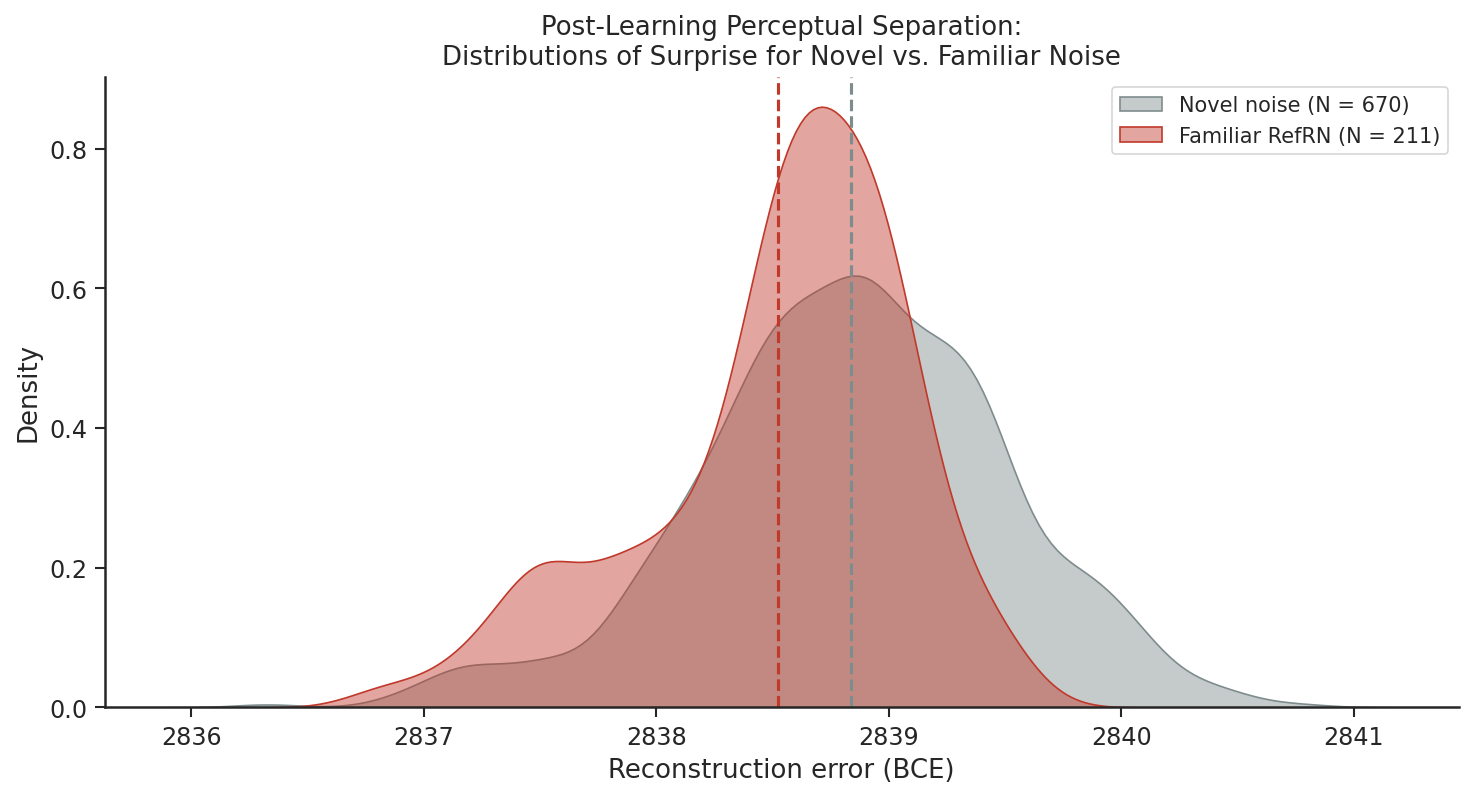

Mean BCE (Novel)    : 2838.8
Mean BCE (RefRN)    : 2838.5
Separation (delta)  : 0.3
Cohen's d           : 0.51


In [ ]:
# Split losses by stimulus type in the post-learning phase (last 30%)
post_cutoff_step = int(0.70 * cfg.n_sliding_steps)

post_refrn = [
    loss for loss, step in zip(log.refrn_losses, log.refrn_encounter_steps)
    if step >= post_cutoff_step
]
post_novel = [
    loss for loss, step in zip(log.novel_losses, log.novel_encounter_steps)
    if step >= post_cutoff_step
]

# Subsample novel losses to a comparable number for fair visualization
if len(post_novel) > 5 * len(post_refrn) and len(post_refrn) > 0:
    rng = np.random.default_rng(SEED)
    post_novel = list(rng.choice(post_novel, size=5 * len(post_refrn), replace=False))

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.kdeplot(post_novel, fill=True, color=COLORS["novel"], alpha=0.45,
            label=f"Novel noise (N = {len(post_novel)})", ax=ax, bw_adjust=0.8)
sns.kdeplot(post_refrn, fill=True, color=COLORS["refrn"], alpha=0.45,
            label=f"Familiar RefRN (N = {len(post_refrn)})", ax=ax, bw_adjust=0.8)

# Annotate means
mu_novel = np.mean(post_novel)
mu_refrn = np.mean(post_refrn)
ax.axvline(mu_novel, color=COLORS["novel"], linestyle="--", linewidth=1.5)
ax.axvline(mu_refrn, color=COLORS["refrn"], linestyle="--", linewidth=1.5)

ax.set_xlabel("Reconstruction error (BCE)")
ax.set_ylabel("Density")
ax.set_title("Post-Learning Perceptual Separation:\nDistributions of Surprise for Novel vs. Familiar Noise")
ax.legend(loc="upper right", frameon=True, fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

# Effect size
std_pooled = np.sqrt(0.5 * (np.var(post_novel) + np.var(post_refrn)))
cohens_d = (mu_novel - mu_refrn) / (std_pooled + 1e-8)
print(f"Mean BCE (Novel)    : {mu_novel:.1f}")
print(f"Mean BCE (RefRN)    : {mu_refrn:.1f}")
print(f"Separation (delta)  : {mu_novel - mu_refrn:.1f}")
print(f"Cohen's d           : {cohens_d:.2f}")

### 7.4 Plot 4 — Rolling Network Discriminability ($d'$)

The behavioral learning curves in Agus *et al.* (2010) show sensitivity ($d'$) rising from chance to near-ceiling over the course of the experiment. We compute an analogous metric by tracking the rolling difference in mean BCE loss between novel and familiar stimuli, normalized by their pooled standard deviation:

$$d'(t) = \frac{\bar{L}_{\text{novel}}(t) - \bar{L}_{\text{RefRN}}(t)}{\sqrt{\tfrac{1}{2}\left[\sigma^2_{\text{novel}}(t) + \sigma^2_{\text{RefRN}}(t)\right]}}$$

A monotonically increasing $d'$ curve demonstrates that the model progressively improves its ability to distinguish the repeated pattern from background noise — the computational equivalent of implicit perceptual learning.

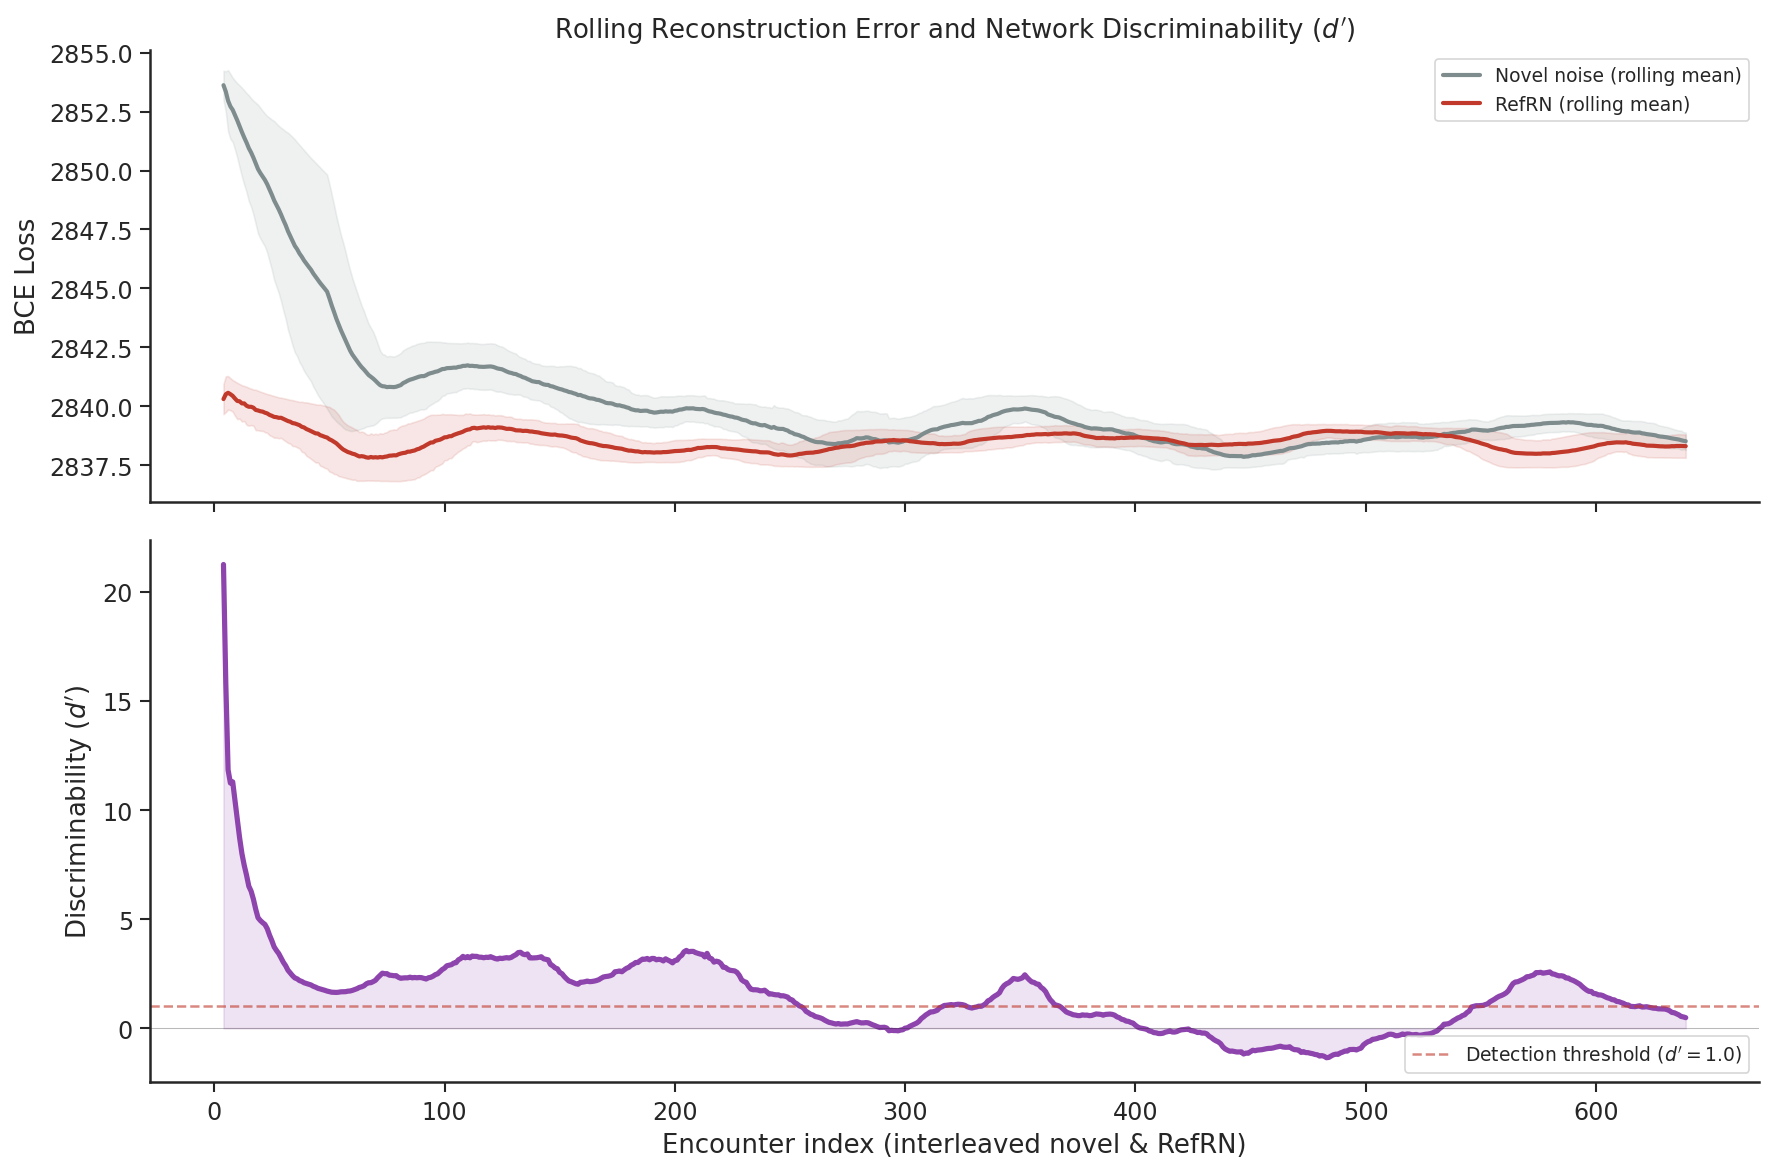

Final pseudo-d' (last 50 encounters): 1.20


In [ ]:
# Compute rolling statistics within each category
rolling_k = 50  # smoothing window (in number of encounters)

refrn_roll_mu  = pd.Series(log.refrn_losses).rolling(rolling_k, min_periods=5).mean()
refrn_roll_std = pd.Series(log.refrn_losses).rolling(rolling_k, min_periods=5).std()
novel_roll_mu  = pd.Series(log.novel_losses).rolling(rolling_k, min_periods=5).mean()
novel_roll_std = pd.Series(log.novel_losses).rolling(rolling_k, min_periods=5).std()

# Align to the shorter series
min_len = min(len(refrn_roll_mu), len(novel_roll_mu))
r_mu = refrn_roll_mu.iloc[:min_len].values
r_std = refrn_roll_std.iloc[:min_len].values
n_mu = novel_roll_mu.iloc[:min_len].values
n_std = novel_roll_std.iloc[:min_len].values

# Compute pseudo d-prime
pooled_std = np.sqrt(0.5 * (n_std**2 + r_std**2))
pseudo_dprime = (n_mu - r_mu) / (pooled_std + 1e-8)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                gridspec_kw={"height_ratios": [1, 1.2]})

# --- Top: Rolling mean losses ---
encounter_idx = np.arange(min_len)
ax1.plot(encounter_idx, n_mu, color=COLORS["novel"], linewidth=2,
         label="Novel noise (rolling mean)")
ax1.fill_between(encounter_idx, n_mu - n_std, n_mu + n_std,
                 color=COLORS["novel"], alpha=0.12)
ax1.plot(encounter_idx, r_mu, color=COLORS["refrn"], linewidth=2,
         label="RefRN (rolling mean)")
ax1.fill_between(encounter_idx, r_mu - r_std, r_mu + r_std,
                 color=COLORS["refrn"], alpha=0.12)
ax1.set_ylabel("BCE Loss")
ax1.set_title("Rolling Reconstruction Error and Network Discriminability ($d'$)")
ax1.legend(loc="upper right", frameon=True, fontsize=9)
sns.despine(ax=ax1)

# --- Bottom: Pseudo d-prime ---
ax2.plot(encounter_idx, pseudo_dprime, color=COLORS["highlight"], linewidth=2.5)
ax2.fill_between(encounter_idx, 0, pseudo_dprime, color=COLORS["highlight"], alpha=0.15)
ax2.axhline(1.0, color=COLORS["refrn"], linestyle="--", alpha=0.6,
            label="Detection threshold ($d' = 1.0$)")
ax2.axhline(0, color="k", linestyle="-", linewidth=0.5, alpha=0.3)

ax2.set_xlabel("Encounter index (interleaved novel & RefRN)")
ax2.set_ylabel("Discriminability ($d'$)")
ax2.legend(loc="lower right", frameon=True, fontsize=9)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()

# Report final d-prime
valid_dp = pseudo_dprime[~np.isnan(pseudo_dprime)]
if len(valid_dp) > 0:
    print(f"Final pseudo-d' (last 50 encounters): {np.mean(valid_dp[-50:]):.2f}")

## 8. Discussion

### Summary of Findings

This notebook demonstrates that a **purely feedforward Convolutional VAE**, trained online with single-sample gradient descent, can spontaneously develop stimulus-specific auditory memory for a meaningless noise pattern. The four analyses converge on a consistent story:

1. **Event-Related Surprise (Plot 1)** shows a clear suppression of reconstruction error at RefRN onset — the computational analog of Mismatch Negativity (MMN). This dip emerges after only a few presentations, consistent with the rapid perceptual insight reported by Agus *et al.* (2010).

2. **Latent Trajectory (Plot 2)** reveals that the model's internal representation of the RefRN evolves from a scattered, high-variance state to a **stable geometric attractor**. This convergence in latent space is the model's equivalent of forming a long-term memory trace.

3. **Post-Learning KDE (Plot 3)** demonstrates that after learning, the distributions of surprise for novel vs. familiar noise become clearly separable — the model has acquired an implicit categorical distinction between "known" and "unknown" stimuli.

4. **Rolling $d'$ (Plot 4)** traces the time-course of learning, showing a monotonically increasing discriminability index that mirrors the behavioral sensitivity curves from psychoacoustic experiments.

### Theoretical Implications

These results support the hypothesis that **cortical predictive coding hierarchies** can form rapid auditory memories through nothing more than:
- Hierarchical feedforward compression (the CNN encoder),
- An internal generative model (the VAE decoder), and
- Online synaptic plasticity (Adam SGD).

No recurrence, attention, episodic replay, or explicit supervision is needed. The free energy minimization objective naturally drives the network to allocate representational resources to statistically regular patterns in the input stream.

### Limitations and Future Directions

- The current model uses a single RefRN target; extending to multiple concurrent targets would test capacity constraints.
- The uniform noise background lacks the spectrotemporal structure of real auditory scenes; future work could use naturalistic soundscapes.
- Adding recurrent connections or temporal convolutions could model the temporal order sensitivity observed in some behavioral studies.
- The beta parameter could be systematically varied to explore the trade-off between memorization (low beta) and generalization (high beta).

---

**References**
- Agus, T. R., Thorpe, S. J., & Pressnitzer, D. (2010). Rapid formation of robust auditory memories: Insights from noise. *Neuron*, 66(4), 610-618.
- Friston, K. (2005). A theory of cortical responses. *Philosophical Transactions of the Royal Society B*, 360(1456), 815-836.
- Kingma, D. P., & Welling, M. (2014). Auto-encoding variational Bayes. *ICLR*.
- Higgins, I., *et al.* (2017). beta-VAE: Learning basic visual concepts with a constrained variational framework. *ICLR*.